In [2]:
import enum
from itertools import count
from logging import raiseExceptions
import os
import tarfile
import pdb
import copy
import csv
import pickle
import io
from scipy.stats.morestats import Std_dev
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from statistics import stdev
import json
import time
import math
import matplotlib.cm as cm
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
from scipy.spatial import distance
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from scipy.spatial import distance
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.stats import wasserstein_distance, pearsonr, spearmanr
from plotnine import ggplot, ggtitle, labs, geom_line,geom_label, geom_ribbon, geom_point, aes, geom_text, stat_smooth, facet_wrap, geom_boxplot, geom_histogram, xlim, ylim, facet_grid
from kmodes.kmodes import KModes
import nibabel as nib
from multiprocessing import Process
from multiprocessing import Pool 
from multiprocessing import Manager
from nilearn import plotting
from nilearn import image
import nibabel as nib
import numpy as np
import os
import ast
import matplotlib.font_manager
plt.rcParams.update({'font.size': 25})


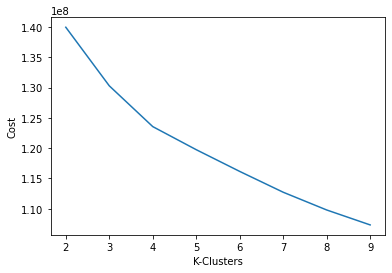

/home/rk1593/.conda/envs/wedding_schema/lib/python3.8/site-packages/matplotlib/mpl-data/matplotlibrc


# Silhoutte

In [17]:
def get_cluster_id_to_distilled_searchlights(K, distill_numLights,
                      exaggerated_0, weight_it, cap_zero, fraction, threshold, by_sil, power_weight):
    cluster_id_to_distilled_lights = {}
    for cluster_id in range(1,K+1):
        ranks_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K" + str(K) + "/kmeans" + str(K) + "cluster" + str(cluster_id) + "_ranks"
        if by_sil:
            ranks_dir += "_by_silhouttes"
        else:
            if exaggerated_0:
                ranks_dir += ("_Consider0_T" + str(threshold))
            else:
                ranks_dir += "_NoConsider0"
            if weight_it:
                ranks_dir += ("_WeightByMean" + str(power_weight))
            else:
                ranks_dir += "_NoWeightByMean"
            if cap_zero:
                ranks_dir += "_CapZero"
            else:
                ranks_dir += "_NoCapZero"
        ranks_dir += ".csv"
        print(ranks_dir)
        ranks_df = pd.read_csv(ranks_dir)
        ranked_searchlights_in_cluster = ranks_df["searchlights_in_cluster"].tolist()
        if fraction:
            cluster_id_to_distilled_lights[cluster_id] = ranked_searchlights_in_cluster[0:int(distill_numLights*len(ranked_searchlights_in_cluster))]
        else: 
            cluster_id_to_distilled_lights[cluster_id] = ranked_searchlights_in_cluster[0:distill_numLights]

    return cluster_id_to_distilled_lights



185405
185405
5 clusters , Average silhoutte Score: 0.09378297667772645


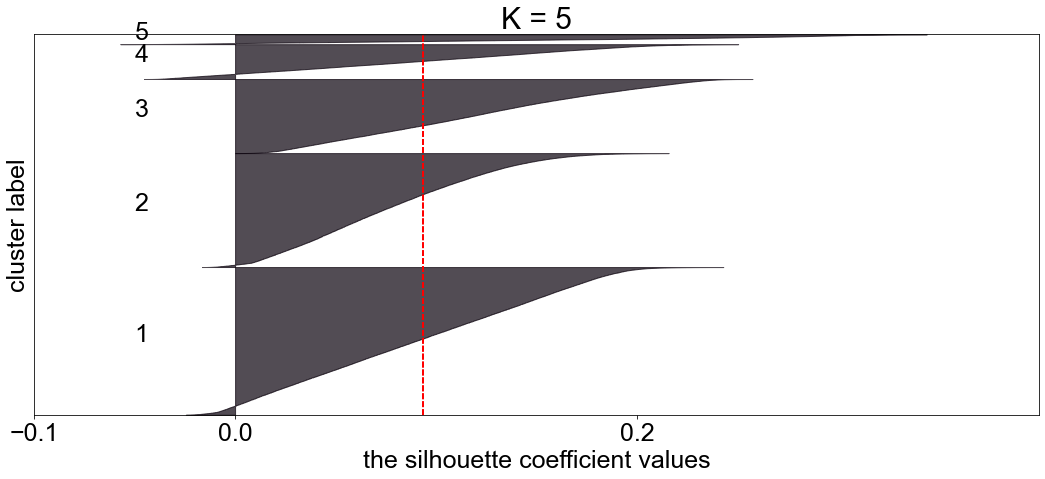

In [18]:
sil_avg_list = []
exaggerated_0 = False
weight_it = True
power_weight = 3
cap_zero = False
distill_it = False
distill_numLights = 0.2
fraction = True
threshold = 1.7
by_sil = False
matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] =  "Arial"
for K in range(5,6):
    # get silhouttes
    in_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_silhouette_tval/kmeans" + str(K) + "_silhouttes_tval.csv"
    labels_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) + "clusters_tval.csv"
    df = pd.read_csv(labels_dir)
    cluster_labels = np.array(df["cluster_assignment"].tolist())
    searchlight_np = np.array((df["searchlight"].tolist()))
    sample_silhouette_values = np.loadtxt(in_dir, delimiter = ",")
    print(len(sample_silhouette_values))
    silhouette_avg = sum(sample_silhouette_values) / len(sample_silhouette_values)
    sil_avg_list.append(silhouette_avg)
    if distill_it:
        cluster_id_to_distilled_lights = get_cluster_id_to_distilled_searchlights(K, distill_numLights, exaggerated_0, weight_it, cap_zero, fraction, threshold, by_sil, power_weight)
        all_lights_thisK = []
        for key in cluster_id_to_distilled_lights:
            for x in cluster_id_to_distilled_lights[key]:
                all_lights_thisK.append(x)
        filter_list = [True if light_id in all_lights_thisK else False for light_id in searchlight_np]
        searchlight_np = searchlight_np[filter_list]
        cluster_labels = cluster_labels[filter_list]
        sample_silhouette_values = sample_silhouette_values[filter_list]
    print(len(sample_silhouette_values))
    print(K, "clusters", ", Average silhoutte Score:", silhouette_avg)
    #plt.hist(sample_silhouette_values)
    n_clusters = K
    # plot them
    fig, (ax1) = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)
    ax1.set_xlim([-0.1, 0.4])
    ax1.set_ylim([0, len(cluster_labels) + (n_clusters + 1) * 10])
    y_lower = 10
    for i in range(1,n_clusters + 1):
      
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(1)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # 10 for the 0 samples
        ax1.set_title("K = " + str(K))
        ax1.set_xlabel("the silhouette coefficient values")
        ax1.set_ylabel("cluster label")
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2])
    plt.savefig("sil.pdf", format = "pdf")


False
False
False
False


KeyboardInterrupt: 

0

Text(0.5, 1.0, 'silhoutte avg across K clusters in range [2,7]')

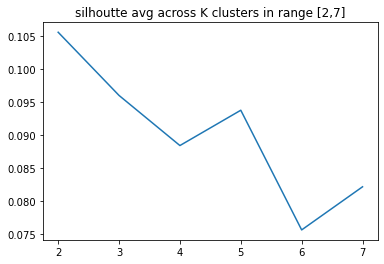

In [9]:
plt.plot([x for x in range(2,8)], sil_avg_list)
plt.title("silhoutte avg across K clusters in range [2,7]")


In [ ]:

def sort_list(ranks, lights):
    zipped_pairs = zip(ranks, lights)
    new_ranks = []
    new_lights = []
    for r,l in sorted(zipped_pairs, reverse= True):
        new_ranks.append(r)
        new_lights.append(l)
    return new_ranks, new_lights


# for each cluster, get the mean of that cluster
K = 5
labels_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) + "clusters_tval.csv"
df = pd.read_csv(labels_dir)
cluster_labels = df["cluster_assignment"]
searchlight_list = np.load("/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/master_searchlight_tval.npy")
X = np.load("/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/master_X_list_tval.npy")
silhouttes_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_silhouette_tval/kmeans" + str(K) + "_silhouttes_tval.csv"
searchlights_rank_list = np.loadtxt(silhouttes_dir, delimiter = ",")
processes_list = []
for cluster_id in set(cluster_labels):
    searchlights_in_cluster = searchlight_list[cluster_labels == cluster_id]
    searchlights_in_cluster_ranks = searchlights_rank_list[cluster_labels == cluster_id]
    new_ranks, new_lights = sort_list(ranks = searchlights_in_cluster_ranks, lights = searchlights_in_cluster)
    output_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K" + str(K) + "/kmeans" + str(K) + "cluster" + str(cluster_id) + "_ranks_by_silhouttes.csv"
    df = pd.DataFrame({"searchlights_rank": new_ranks,
                       "searchlights_in_cluster":new_lights})
    df.to_csv(output_dir)

# Colored Brain

In [11]:

def get_cluster_id_to_distilled_searchlights(K, distill_numLights,
                      exaggerated_0, weight_it, cap_zero, fraction, threshold, by_sil, power_weight):
    cluster_id_to_distilled_lights = {}
    for cluster_id in range(1,K+1):
        ranks_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K" + str(K) + "/kmeans" + str(K) + "cluster" + str(cluster_id) + "_ranks"
        if by_sil:
            ranks_dir += "_by_silhouttes"
        else:
            if exaggerated_0:
                ranks_dir += ("_Consider0_T" + str(threshold)) 
            else:
                ranks_dir += "_NoConsider0"
            if weight_it:
                ranks_dir += ("_WeightByMean" + str(power_weight))
            else:
                ranks_dir += "_NoWeightByMean"
            if cap_zero:
                ranks_dir += "_CapZero"
            else:
                ranks_dir += "_NoCapZero"
        ranks_dir += ".csv"
        print(ranks_dir)
        ranks_df = pd.read_csv(ranks_dir)
        ranked_searchlights_in_cluster = ranks_df["searchlights_in_cluster"].tolist()
        if fraction:
            cluster_id_to_distilled_lights[cluster_id] = ranked_searchlights_in_cluster[0:int(distill_numLights*len(ranked_searchlights_in_cluster))]
        else: 
            cluster_id_to_distilled_lights[cluster_id] = ranked_searchlights_in_cluster[0:distill_numLights]

    return cluster_id_to_distilled_lights

def plot_colored_brain(K,cluster_assignment_csv_path, brain_image_path, optional_focus = None,
                               colored_brain_np = [], distill_it = False, distill_numLights = 1000,by_sil = True,
                      exaggerated_0 = False, weight_it = True,
                       cap_zero = False, fraction = False, threshold = None, power_weight = None):
    """
    This function plots a colored brain based on the cluster assignment of kmodes

    cluster_assignment_csv_path: data frame with columns: "cluster_assignment", "searchlight", "features"

    brain_image_path: shape (97, 115, 97) image which will be used to get the affine and header

    output_path: where these plots will end up saved
    """
    # get the brain_image_path
    matplotlib.rcParams['font.family'] = "sans-serif"
    matplotlib.rcParams['font.sans-serif'] =  "Arial"
    img = nib.load(brain_image_path)
    if distill_it:
        cluster_id_to_distilled_lights = get_cluster_id_to_distilled_searchlights(K, distill_numLights, exaggerated_0, weight_it, cap_zero, fraction, threshold, by_sil, power_weight)
    # get colored_brain_np if it is not fed in
    if len(colored_brain_np) == 0:
        # get the cluster assignment
        df = pd.read_csv(cluster_assignment_csv_path)
        colored_brain_np = np.zeros(shape=(97, 115, 97))
        # colored_brain_np = colored_brain_np.astype(float)
        # populate the brain_np with the cluster assignment
        for index,row in df.iterrows():
            light_id_splitted = row["searchlight"].split("_")
            light_id_str = row["searchlight"]
            cluster_id = int(row["cluster_assignment"])
            if distill_it and light_id_str not in cluster_id_to_distilled_lights[cluster_id]:
                continue
            x = int(light_id_splitted[0])
            y = int(light_id_splitted[1])
            z = int(light_id_splitted[2])
            colored_brain_np[x,y,z] = int(row["cluster_assignment"])
    original_colored_brain_np = copy.copy(colored_brain_np)
    if optional_focus != None:
        colored_brain_np[colored_brain_np != optional_focus] = 0
    # turn into nifti and plot with nilearn
    colored_brain = nib.Nifti1Image(colored_brain_np, affine=img.affine, header = img.header, extra = img.extra)
    print("optional_focus: ", optional_focus)
    print("len(np.unique(colored_brain_np)): ", len(np.unique(colored_brain_np)))
    print(np.unique(colored_brain_np))
    display = plotting.plot_roi(colored_brain, draw_cross = False, cut_coords = (-4,-30,20), colorbar = True, cmap = cm.get_cmap('Spectral', 20), title =  "" )#"K = " + str(K) + " & Focus Cluster = " + str(optional_focus) )
    plt.savefig("map5.pdf", format = "pdf")
    plt.show()#savefig("map.pdf", format = "pdf")
    display.close()
    return original_colored_brain_np
    

optional_focus:  None
len(np.unique(colored_brain_np)):  6
[0. 1. 2. 3. 4. 5.]


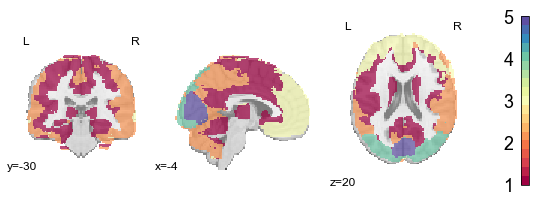

In [12]:
K = 5
colored_brain_np6 = plot_colored_brain(K = K,
                cluster_assignment_csv_path = "/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) +  "clusters_tval.csv",
                       brain_image_path = "/home/rk1593/wedding_schema/code/python/kmodes/rentireAAL_wfupickatlas.nii", 
                        by_sil = False,
                        exaggerated_0 = False, weight_it = True, cap_zero = False,
                        power_weight = 1,
                        distill_it = False,
                        distill_numLights = 0.5,
                        fraction = True,
                        threshold = 0.5,
                        optional_focus = None,
                       colored_brain_np = []#colored_brain_np6              
                        )






/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K5/kmeans5cluster1_ranks_NoConsider0_WeightByMean_NoCapZero.csv
/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K5/kmeans5cluster2_ranks_NoConsider0_WeightByMean_NoCapZero.csv
/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K5/kmeans5cluster3_ranks_NoConsider0_WeightByMean_NoCapZero.csv
/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K5/kmeans5cluster4_ranks_NoConsider0_WeightByMean_NoCapZero.csv
/scratch/gpfs/rk1593/clustering_output/kmeans_searchlight_ranks/K5/kmeans5cluster5_ranks_NoConsider0_WeightByMean_NoCapZero.csv
optional_focus:  None
len(np.unique(colored_brain_np)):  6
[0. 1. 2. 3. 4. 5.]


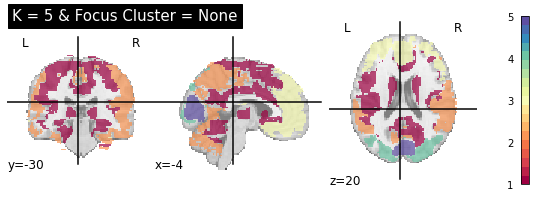

In [15]:


K = 5
colored_brain_np6 = plot_colored_brain(K = K,
            cluster_assignment_csv_path = "/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) +  "clusters_tval.csv",
                   brain_image_path = "/home/rk1593/wedding_schema/code/python/kmodes/rentireAAL_wfupickatlas.nii", 
                    exaggerated_0 = False, weight_it = True, cap_zero = False,
                    distill_it = True,
                    distill_numLights = 0.75,
                    fraction = True,
                    threshold = 1.7,
                    optional_focus = None,
                   colored_brain_np = []#colored_brain_np6              
                    )


5809

# Fingerprints

In [22]:
alpha = 0.1
n_clusters = 7
event_template_id = 4
cluster_id = 2
raw_df = pd.read_csv("/scratch/gpfs/rk1593/clustering_output/kmodes_fingerprints_alpha" + str(alpha) + "/kmodes_" + str(K) + "clusters_alpha" + str(alpha) + ".csv")
filtered_df = plot_raw_fingerprint_cluster(raw_df, cluster_id, event_template_id, n_clusters)


,Unnamed: 0,tr,path_id,event_template_id,cluster_id,corr,std,n,lower_bound,upper_bound,event_matching_id
0,0,0,sameEv-sameSchema,2,4,-0.019908,0.033550,40,-0.025213,-0.014603,0
1,1,1,sameEv-sameSchema,2,4,-0.010857,0.038340,40,-0.016919,-0.004795,0
2,2,2,sameEv-sameSchema,2,4,-0.017782,0.031679,40,-0.022790,-0.012773,0
3,3,3,sameEv-sameSchema,2,4,-0.021273,0.032173,40,-0.026360,-0.016186,0
4,4,4,sameEv-sameSchema,2,4,-0.022491,0.030392,40,-0.027297,-0.017686,0
...,...,...,...,...,...,...,...,...,...,...,...
8875,8875,3,otherEv-otherSchema,4,2,-0.008061,0.034619,40,-0.013535,-0.002588,5
8876,8876,4,otherEv-otherSchema,4,2,-0.011262,0.032538,40,-0.016407,-0.006118,5
8877,8877,5,otherEv-otherSchema,4,2,-0.008723,0.031922,40,-0.013770,-0.003675,5
8878,8878,6,otherEv-otherSchema,4,2,-0.009074,0.033040,40,-0.014298,-0.003850,5


In [25]:
filtered_df

,Unnamed: 0,tr,path_id,event_template_id,cluster_id,corr,event_matching_id
7719,7719,0,correct-path,4,2,-0.001140,2
7720,7720,1,correct-path,4,2,0.000225,2
7721,7721,2,correct-path,4,2,0.000320,2
7722,7722,3,correct-path,4,2,-0.001190,2
7723,7723,4,correct-path,4,2,-0.000161,2
...,...,...,...,...,...,...,...
7979,7979,11,unrelated-path,4,2,-0.012656,4
7980,7980,12,unrelated-path,4,2,-0.015350,4
7981,7981,13,unrelated-path,4,2,-0.013177,4
7982,7982,14,unrelated-path,4,2,-0.014639,4


# Get mode of a cluster

In [35]:
def get_mean_of_cluster(K, cluster_id):
  
    df_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) + "clusters_tval.csv"
    df = pd.read_csv(df_dir)
    cluster_labels = np.array(df["cluster_assignment"].tolist())
    X = np.load("/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/master_X_list_tval.npy")
    vectors_in_cluster = X[cluster_labels == cluster_id,:]
    from scipy import stats
    mode = stats.mode(vectors_in_cluster)
    return vectors_in_cluster,mode

In [45]:
K = 6
cluster_id = 1
with open("/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval/kmeans_" + str(K) + "clusters_tval.pickle", 'rb') as pickle_file:
    kmeans_load = pickle.load(pickle_file)
for cluster_id, centroid in enumerate(kmeans_load.cluster_centers_):
    print(np.mean(abs(centroid)))
    print(len(centroid))
kmeans_load.cluster_centers_[-1]

0.509408092619632
774
0.543729971034921
774
0.6856655764873271
774
0.8785662768726746
774
1.208529645875128
774
0.429157610262731
774


array([ 0.2080994 , -0.24582013, -0.31358386, -0.2321423 , -0.11015746,
       -0.29315953,  0.68134132,  0.14151127,  0.18098677, -0.1712079 ,
       -0.10207701,  0.2870257 , -0.1548789 , -0.55632456,  0.03958963,
       -0.56784284, -0.87672932, -0.49937818, -0.24861054, -0.02930502,
        0.70707598,  0.31482823,  0.28816558,  0.97759009, -0.17757279,
        0.54561449,  0.07974906,  0.0887128 , -0.02346161,  0.86519598,
       -0.24242126,  0.70882329,  0.62402234,  0.39417278,  0.23516439,
       -0.04801771, -0.21416918,  0.35253265,  0.45242577, -0.01204111,
        0.26436206,  0.30324068,  0.29583291, -0.08216218,  0.11060307,
       -0.27929057, -0.64284654, -0.06760134, -0.71853085, -0.02209412,
       -0.17587906, -0.02989345, -0.06980482, -0.30641534,  0.59650643,
       -0.71857079, -0.43936827, -0.50269695, -0.31021383, -0.55351018,
       -0.38620717,  0.19535177,  0.58948595,  0.71880271,  0.78171153,
        0.79984085,  1.38635908,  0.59565717,  0.70503087,  0.56

In [7]:
#len(np.mean(vectors_in_cluster, axis = 0))
vectors_in_cluster

array([[-1.,  0., -1., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0., -1., ...,  1.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

In [174]:
K = 8
for cluster_id in range(1,9):
    vectors_in_cluster,mode = get_mode_of_cluster(K, cluster_id)
    # get the average count of nonzero
    count_all_zero = 0
    num_non_zeros_list = []
    for vector in vectors_in_cluster:
        #print(vector)
        num_non_zeros_list.append(len(np.where(vector != 0)[0]))
        if len(np.where(vector != 0)[0]) == 0:
            count_all_zero += 1
    print(count_all_zero, len(vectors_in_cluster), sum(num_non_zeros_list) / len(num_non_zeros_list))

0 14404 241.54089141905027
0 6557 183.74759798688424
0 67019 163.34121666989958
0 22503 228.63955916988846
0 15511 231.83334407839598
0 5037 355.2515386142545
0 31763 237.40015111922676
0 22611 330.97651585511477


In [13]:
# import enum
# from itertools import count
# from logging import raiseExceptions
# import os
# import tarfile
# import pdb
# import csv
# import io
# from scipy.stats.morestats import Std_dev
# from sklearn.feature_extraction.text import CountVectorizer
# import numpy as np
# from sklearn.decomposition import LatentDirichletAllocation
# from statistics import stdev
# import json
# import time
# import math
# import matplotlib.cm as cm
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib import pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import matplotlib.patches as patches
# from scipy.spatial import distance
# from sklearn.datasets import make_blobs
# from sklearn.cluster import KMeans
# from scipy.spatial import distance
# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_samples, silhouette_score
# from scipy.stats import wasserstein_distance, pearsonr, spearmanr
# from plotnine import ggplot, ggtitle, labs, geom_line,geom_label, geom_point, aes, geom_text, stat_smooth, facet_wrap, geom_boxplot, geom_histogram, xlim, ylim, facet_grid
# from kmodes.kmodes import KModes
# import nibabel as nib
# from multiprocessing import Process
# from multiprocessing import Pool 
# from multiprocessing import Manager
# from nilearn import plotting
# from nilearn import image
# import nibabel as nib
# import numpy as np
# import os



# # def trinary_distance_matrix(N_vectors):
# #     N = len(N_vectors)
# #     matrix = np.zeros((N,N),  dtype="float32")
# #     for i in range(N):
# #         if i % 10000 == 0:
# #             print("making distance matrix", i)
# #         for j in range(N):
# #             matrix[i,j] = distance.hamming(N_vectors[i], N_vectors[j]) #sum(np.array(N_vectors[i]) != np.array(N_vectors[j])) / len(N_vectors[i])
# #     return matrix

# def divide_chunks(all_indices, chunk_size):
#     # looping till length l
#     for i in range(0, len(all_indices), chunk_size): 
#         yield all_indices[i:i + chunk_size]

    
# def add_to_distance_matrix(chunk_of_indices, return_dict, N, N_vectors):
#     for index_of_chunk,i in enumerate(chunk_of_indices):
#         print("making distance_matrix: ", index_of_chunk) 
#         new_dict = {}
#         for key in return_dict:
#             new_dict[key] = return_dict[key]
#         print(new_dict)
#         start_time = time.time()
#         for j in range(N):
#             if j % 30000 == 0:
#                 print(j)
# #             if (str(i) + "_" + str(j)) in return_dict or (str(j) + "_" + str(i)) in return_dict:
# #                 continue
       
#             return_dict[str(i) + "_" + str(j)] = distance.hamming(N_vectors[i], N_vectors[j]) #sum(np.array(N_vectors[i]) != np.array(N_vectors[j])) / len(N_vectors[i])
#         print("timing: ", time.time() - start_time)
# # compute distance matrix based on hamming
# def trinary_distances(N_vectors, num_chunks):
#     N = len(N_vectors)
#     all_indices = [i for i in range(N)]
#     if num_chunks == 1:
#         chunks_of_all_indices = [all_indices]
#     else:
#         chunk_size = math.floor(len(all_indices) / num_chunks)
#         chunks_of_all_indices = list(divide_chunks(all_indices = all_indices, chunk_size = chunk_size))
#     manager = Manager()
#     return_dict = manager.dict()
#     processes_list = []
#     for chunk in chunks_of_all_indices:
#          add_to_distance_matrix(chunk, return_dict, N, N_vectors)
# #         new_p = Process(target = add_to_distance_matrix,
# #                         args = (chunk, return_dict, N, N_vectors))
# #         new_p.start()
# #         processes_list.append(new_p)
# #     for p in processes_list:
# #         p.join()
#     new_dict = {}
#     for key in return_dict:
#         new_dict[key] = return_dict[key]
#     return new_dict


# def get_vectors(dir, num_chunks, X_list = None):
#     if X_list == None:
#         X_list = np.load(dir + "kmodes_assignments/master_X_list.npy").tolist()
#     print("got X_list")
#     distance_matrix = trinary_distances(X_list, num_chunks) 
#     np.save(dir + "kmodes_assignments/master_distance_matrix.npy", distance_matrix)
#     print("got distance matrix")


In [20]:
# dir = "/scratch/gpfs/rk1593/clustering_output/" 
# X = np.load(dir + "kmodes_assignments/master_X_list.npy")
# all_indices = [i for i in range(len(X))]
# def divide_chunks(all_indices, chunk_size):
#     # looping till length l
#     for i in range(0, len(all_indices), chunk_size): 
#         yield all_indices[i:i + chunk_size]
# num_chunks = 199
# chunk_size = math.floor(len(all_indices) / num_chunks)
# chunks_of_all_indices = list(divide_chunks(all_indices = all_indices, chunk_size = chunk_size))
# job_dict = {}
# for chunk_index, chunk in enumerate(chunks_of_all_indices):
#     job_dict[chunk_index] = chunk
# f = open(dir + "creating_distance_matrix_jobs.json", "w")
# json.dump(job_dict, f)    

array([[0],
       [1],
       [2]])

In [ ]:
# import enum
# from itertools import count
# from logging import raiseExceptions
# import os
# import tarfile
# import pdb
# import csv
# import io
# from scipy.stats.morestats import Std_dev
# from sklearn.feature_extraction.text import CountVectorizer
# import numpy as np
# from sklearn.decomposition import LatentDirichletAllocation
# from statistics import stdev
# import json
# import time
# import math
# import matplotlib.cm as cm
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib import pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import matplotlib.patches as patches
# from scipy.spatial import distance
# from sklearn.datasets import make_blobs
# from sklearn.cluster import KMeans
# from scipy.spatial import distance
# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_samples, silhouette_score
# from scipy.stats import wasserstein_distance, pearsonr, spearmanr
# from plotnine import ggplot, ggtitle, labs, geom_line,geom_label, geom_point, aes, geom_text, stat_smooth, facet_wrap, geom_boxplot, geom_histogram, xlim, ylim, facet_grid
# from kmodes.kmodes import KModes
# import nibabel as nib
# from multiprocessing import Process
# from multiprocessing import Pool 
# from multiprocessing import Manager
# from nilearn import plotting
# from nilearn import image
# import nibabel as nib
# import numpy as np
# import os
# import ast

# coordinates_to_true_cluster = {
#     "46_min64_0":1,
#    # "43_min70_7":1, # this is ignored since it is missing files
#     "48_min67_2":1,
#     "48_min63_9":1,
#     "44_min67_5":1,
#     "53_min66_6":1,
#     "45_min66_10":1,
#     "43_min69_4":1,
#     "56_min68_4":1,
#     "42_min62_4":1,
#     "48_min65_8":1,
#     "48_min62_3":1,
#     "0_min80_10":2,
#     "8_min84_15":2,
#     "min7_min85_11":2,
#     "min8_min81_7":2,
#     "min12_min84_7":2,
#     "5_min84_10":2,
#     "min3_min83_15":2,
#     "min3_min77_8":2,
#     "min5_min77_7":2,
#     "min10_min84_7":2,
#     "min1_min84_13":2,
#     "min6_min84_14":2
# }

# all_compare_names = ['sameEv-sameSchema_sameEv-otherSchema',
#                         'sameEv-sameSchema_otherEv-sameSchema',
#                         'sameEv-sameSchema_otherEv-otherSchema',
#                         'sameEv-otherSchema_otherEv-sameSchema',
#                         'sameEv-otherSchema_otherEv-otherSchema',
#                         'otherEv-sameSchema_otherEv-otherSchema']



# # "/Users/rosskempner/opt/anaconda3/envs/mybrainiak/lib/python3.6/site-packages/sklearn/metrics/cluster"

# testing_searchlight_indices = [0,1,2,3,4,5]

# # (first_index, last_index)
# # this is if we are including all events
# matching_id_labels_each_tr = []
# for i in range(0,17):
#     matching_id_labels_each_tr.append(0)
# for i in range(17,23):
#     matching_id_labels_each_tr.append(1)
# for i in range(23,34):
#     matching_id_labels_each_tr.append(2)
# for i in range(34,50):
#     matching_id_labels_each_tr.append(3)
# for i in range(50,66):
#     matching_id_labels_each_tr.append(4)
# for i in range(66,74):
#     matching_id_labels_each_tr.append(5)

# # this is if we are including just events 2,3 and 4

# event_1_start = 17
# event_2_start = 23
# event_3_start = 34
# event_4_start = 50
# event_5_start = 66
# # Event 1 start: TR 17
# # Event 2 start: 23
# # Event 3 start: 34
# # Event 4 start: 50
# # Event 5 start: 66

# def get_num_points_each_cluster_dict(cluster_labels):
#     num_points_each_cluster_dict = {}
#     for cluster_id in set(cluster_labels):
#         count = len(np.where(np.array(cluster_labels) == cluster_id)[0])
#         num_points_each_cluster_dict[cluster_id] = count
#     return num_points_each_cluster_dict

# def get_silhoutte_for_this_K(input_dir, output_dir, K, num_chunks, distance_matrix_path, num_points_each_cluster_dict_path):
#     df = pd.read_csv(input_dir)
#     cluster_labels = df["cluster_assignment"].tolist()
#     print("got cluster labels")
#     # get distance matrix
#     if os.path.exists(distance_matrix_path):
#         distance_matrix = np.load(distance_matrix_path)
#     else:
#         X_list = []
#         for i,x in enumerate(df["features"].tolist()):
#             if i % 10000 == 0:
#                 print("making X_list", i)
#             X_list.append(ast.literal_eval(x))
#         distance_matrix = trinary_distance_matrix(X_list)
#         np.save(distance_matrix_path, distance_matrix)
#     print("got distance matrix")

 
#     # get num_points_each_cluster_dict
#     if os.path.exists(num_points_each_cluster_dict_path):
#         with open(num_points_each_cluster_dict_path) as json_file:
#             num_points_each_cluster_dict = json.load(json_file)
#     else:
#         num_points_each_cluster_dict = get_num_points_each_cluster_dict(cluster_labels)
#         f = open(num_points_each_cluster_dict_path, "w")
#         json.dump(num_points_each_cluster_dict, f)    
#     print("got num_points_each_cluster_dict")

#     # Create a subplot with 1 row and 2 columns
#     fig, (ax1, ax2) = plt.subplots(1, 2)
#     fig.set_size_inches(18, 7)
#     # The 1st subplot is the silhouette plot
#     # The silhouette coefficient can range from -1, 1 but in this example all
#     # lie within [-0.1, 1]
#     ax1.set_xlim([-0.1, 1])
#     # The (n_clusters+1)*10 is for inserting blank space between silhouette
#     # plots of individual clusters, to demarcate them clearly.
#     ax1.set_ylim([0, len(X_list) + (K + 1) * 10])

#     # get silhouette scores
#     silhouette_scores = custom_k_modes_silhouette(cluster_labels, num_chunks, distance_matrix, num_points_each_cluster_dict)
#     silhouette_avg = sum(silhouette_scores) / len(silhouette_scores)
#     print("For K_clusters =", K,
#         "The average silhouette_score is :", silhouette_avg)
#     y_lower = 10
#     sample_silhouette_values = np.array(silhouette_scores)
#     # plot the silhouttes
#     for i in range(K):
#         # Aggregate the silhouette scores for samples belonging to
#         # cluster i, and sort them
#         ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        
#         ith_cluster_silhouette_values.sort()

#         size_cluster_i = ith_cluster_silhouette_values.shape[0]
#         y_upper = y_lower + size_cluster_i

#         color = cm.nipy_spectral(float(i) / K)
#         ax1.fill_betweenx(np.arange(y_lower, y_upper),
#                             0, ith_cluster_silhouette_values,
#                             facecolor=color, edgecolor=color, alpha=0.7)

#         # Label the silhouette plots with their cluster numbers at the middle
#         ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

#         # Compute the new y_lower for next plot
#         y_lower = y_upper + 10  # 10 for the 0 samples

#         ax1.set_title("For K_clusters = " + str(K) +
#                 "The average silhouette_score is :" + silhouette_avg)
#         ax1.set_xlabel("The silhouette coefficient values")
#         ax1.set_ylabel("Cluster label")

#         # The vertical line for average silhouette score of all the values
#         ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

#         ax1.set_yticks([])  # Clear the yaxis labels / ticks
#         ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
#     plt.show()
#     plt.savefig(output_dir)


# def divide_chunks(all_indices, chunk_size):
#     # looping till length l
#     for i in range(0, len(all_indices), chunk_size): 
#         yield all_indices[i:i + chunk_size]

# # compute distance matrix based on hamming
# def trinary_distance_matrix(N_vectors):
#     N = len(N_vectors)
#     matrix = np.zeros((N,N),  dtype="float32")
#     for i in range(N):
#         if i % 10000 == 0:
#             print("making distance_matrix: ", i)
#         for j in range(N):
#             matrix[i,j] = sum(np.array(N_vectors[i]) != np.array(N_vectors[j])) / len(N_vectors[i])
#     return matrix
    

# def process_chunk_of_data(chunk_indices,  all_cluster_labels, return_dict, 
#                             distance_matrix, num_points_each_cluster_dict):
#     # TODO: get the np.where for each cluster in a dictionary just once
#     for index_of_index,data_point_i in enumerate(chunk_indices):
#         print(data_point_i)
#         i_cluster_value = all_cluster_labels[data_point_i]
#         num_points_in_cluster_i = num_points_each_cluster_dict[i_cluster_value]  #len(np.where(np.array(all_cluster_labels) == i_cluster_value)[0])
#         # if just one point in cluster then s_i is zero and don't go through all steps
#         if num_points_in_cluster_i == 1:
#             s_i = 0
#             return_dict[s_i] = -99
#             continue
#         # get a(i), the mean distance between i and all other data points in same cluster
#         a_i_summation = 0
#         times_added = 0
#         for j, j_cluster_value in enumerate(all_cluster_labels):
#             # if same cluster and not same data point
#             if j !=  data_point_i and i_cluster_value == j_cluster_value:
#                 # then add distance to summation
#                 a_i_summation += distance_matrix[data_point_i,j]
#                 times_added += 1
#         a_i = a_i_summation / (num_points_in_cluster_i - 1)
#         # get b(i), the mean distance between i and all the data points in the neighboring cluster
#         mean_distance_to_other_clusters_list = []
#         for cluster_id_k in set(all_cluster_labels):
#             if cluster_id_k != i_cluster_value:
#                 num_points_in_cluster_k = num_points_each_cluster_dict[cluster_id_k]  #len(np.where(np.array(all_cluster_labels) == cluster_id_k)[0])
#                 b_i_summation = 0
#                 times_added = 0
#                 for j, j_cluster_value in enumerate(all_cluster_labels):
#                     if j_cluster_value == cluster_id_k:
#                         b_i_summation += distance_matrix[data_point_i,j]
#                         times_added += 1
#                 mean_to_cluster_k = b_i_summation / num_points_in_cluster_k
#                 mean_distance_to_other_clusters_list.append(mean_to_cluster_k)
#         b_i = min(mean_distance_to_other_clusters_list)
#         # s_i is silhouette value of data point i and
#         # is 0 if we just have 1 data point in cluster
#         s_i = (b_i - a_i) / max([a_i, b_i])
#         return_dict[s_i] = -99

# def custom_k_modes_silhouette(cluster_labels, num_chunks, distance_matrix, num_points_each_cluster_dict):
#     silhouette_scores_each_data_point = []
#     all_indices = [i for i in range(len(cluster_labels))]
#     if num_chunks == 1:
#         chunks_of_all_indices = [all_indices]
#     else:
#         chunk_size = math.floor(len(all_indices) / num_chunks)
#         chunks_of_all_indices = list(divide_chunks(all_indices = all_indices, chunk_size = chunk_size))
#     manager = Manager()
#     return_dict = manager.dict()
#     processes_list = []
#     for chunk in chunks_of_all_indices:
#         process_chunk_of_data(chunk, cluster_labels, return_dict, distance_matrix, num_points_each_cluster_dict)

#     #     new_p = Process(target = process_chunk_of_data, 
#     #                 args = (chunk, cluster_labels, return_dict, distance_matrix, num_points_each_cluster_dict))
#     #     new_p.start()
#     #     processes_list.append(new_p)
#     # for p in processes_list:
#     #     p.join()
#     for key in return_dict:
#         silhouette_scores_each_data_point.append(key)
#     return silhouette_scores_each_data_point


In [ ]:
# import enum
# from itertools import count
# from logging import raiseExceptions
# import os
# import tarfile
# import pdb
# import csv
# import io
# from scipy.stats.morestats import Std_dev
# from sklearn.feature_extraction.text import CountVectorizer
# import numpy as np
# from sklearn.decomposition import LatentDirichletAllocation
# from statistics import stdev
# import json
# import time
# import math
# import matplotlib.cm as cm
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib import pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import matplotlib.patches as patches
# from scipy.spatial import distance
# from sklearn.datasets import make_blobs
# from sklearn.cluster import KMeans
# from scipy.spatial import distance
# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_samples, silhouette_score
# from scipy.stats import wasserstein_distance, pearsonr, spearmanr
# from plotnine import ggplot, ggtitle, labs, geom_line,geom_label, geom_point, aes, geom_text, stat_smooth, facet_wrap, geom_boxplot, geom_histogram, xlim, ylim, facet_grid
# from kmodes.kmodes import KModes
# import nibabel as nib
# from multiprocessing import Process
# from multiprocessing import Pool 
# from multiprocessing import Manager
# from nilearn import plotting
# from nilearn import image
# import nibabel as nib
# import numpy as np
# import os
# import ast

# coordinates_to_true_cluster = {
#     "46_min64_0":1,
#    # "43_min70_7":1, # this is ignored since it is missing files
#     "48_min67_2":1,
#     "48_min63_9":1,
#     "44_min67_5":1,
#     "53_min66_6":1,
#     "45_min66_10":1,
#     "43_min69_4":1,
#     "56_min68_4":1,
#     "42_min62_4":1,
#     "48_min65_8":1,
#     "48_min62_3":1,
#     "0_min80_10":2,
#     "8_min84_15":2,
#     "min7_min85_11":2,
#     "min8_min81_7":2,
#     "min12_min84_7":2,
#     "5_min84_10":2,
#     "min3_min83_15":2,
#     "min3_min77_8":2,
#     "min5_min77_7":2,
#     "min10_min84_7":2,
#     "min1_min84_13":2,
#     "min6_min84_14":2
# }

# all_compare_names = ['sameEv-sameSchema_sameEv-otherSchema',
#                         'sameEv-sameSchema_otherEv-sameSchema',
#                         'sameEv-sameSchema_otherEv-otherSchema',
#                         'sameEv-otherSchema_otherEv-sameSchema',
#                         'sameEv-otherSchema_otherEv-otherSchema',
#                         'otherEv-sameSchema_otherEv-otherSchema']



# # "/Users/rosskempner/opt/anaconda3/envs/mybrainiak/lib/python3.6/site-packages/sklearn/metrics/cluster"

# testing_searchlight_indices = [0,1,2,3,4,5]

# # (first_index, last_index)
# # this is if we are including all events
# matching_id_labels_each_tr = []
# for i in range(0,17):
#     matching_id_labels_each_tr.append(0)
# for i in range(17,23):
#     matching_id_labels_each_tr.append(1)
# for i in range(23,34):
#     matching_id_labels_each_tr.append(2)
# for i in range(34,50):
#     matching_id_labels_each_tr.append(3)
# for i in range(50,66):
#     matching_id_labels_each_tr.append(4)
# for i in range(66,74):
#     matching_id_labels_each_tr.append(5)

# # this is if we are including just events 2,3 and 4

# event_1_start = 17
# event_2_start = 23
# event_3_start = 34
# event_4_start = 50
# event_5_start = 66
# # Event 1 start: TR 17
# # Event 2 start: 23
# # Event 3 start: 34
# # Event 4 start: 50
# # Event 5 start: 66

# def get_num_points_each_cluster_dict(cluster_labels):
#     num_points_each_cluster_dict = {}
#     for cluster_id in set(cluster_labels):
#         count = len(np.where(np.array(cluster_labels) == cluster_id)[0])
#         num_points_each_cluster_dict[cluster_id] = count
#     return num_points_each_cluster_dict

# def get_silhoutte_for_this_K(input_dir, output_dir, K, num_chunks, distance_matrix_path, num_points_each_cluster_dict_path):
#     df = pd.read_csv(input_dir)
#     cluster_labels = df["cluster_assignment"].tolist()
#     print("got cluster labels")
#     # get distance matrix
#     if os.path.exists(distance_matrix_path):
#         distance_matrix = np.load(distance_matrix_path)
#     else:
#         X_list = []
#         for i,x in enumerate(df["features"].tolist()):
#             if i % 10000 == 0:
#                 print("making X_list", i)
#             X_list.append(ast.literal_eval(x))
#         distance_matrix = trinary_distance_matrix(X_list, num_chunks = num_chunks)
#         np.save(distance_matrix_path, distance_matrix)
#     print("got distance matrix")

 
#     # get num_points_each_cluster_dict
#     if os.path.exists(num_points_each_cluster_dict_path):
#         with open(num_points_each_cluster_dict_path) as json_file:
#             num_points_each_cluster_dict = json.load(json_file)
#     else:
#         num_points_each_cluster_dict = get_num_points_each_cluster_dict(cluster_labels)
#         f = open(num_points_each_cluster_dict_path, "w")
#         json.dump(num_points_each_cluster_dict, f)    
#     print("got num_points_each_cluster_dict")

#     # Create a subplot with 1 row and 2 columns
#     fig, (ax1, ax2) = plt.subplots(1, 2)
#     fig.set_size_inches(18, 7)
#     # The 1st subplot is the silhouette plot
#     # The silhouette coefficient can range from -1, 1 but in this example all
#     # lie within [-0.1, 1]
#     ax1.set_xlim([-0.1, 1])
#     # The (n_clusters+1)*10 is for inserting blank space between silhouette
#     # plots of individual clusters, to demarcate them clearly.
#     ax1.set_ylim([0, len(X_list) + (K + 1) * 10])

#     # get silhouette scores
#     silhouette_scores = custom_k_modes_silhouette(cluster_labels, num_chunks, distance_matrix, num_points_each_cluster_dict)
#     silhouette_avg = sum(silhouette_scores) / len(silhouette_scores)
#     print("For K_clusters =", K,
#         "The average silhouette_score is :", silhouette_avg)
#     y_lower = 10
#     sample_silhouette_values = np.array(silhouette_scores)
#     # plot the silhouttes
#     for i in range(K):
#         # Aggregate the silhouette scores for samples belonging to
#         # cluster i, and sort them
#         ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        
#         ith_cluster_silhouette_values.sort()

#         size_cluster_i = ith_cluster_silhouette_values.shape[0]
#         y_upper = y_lower + size_cluster_i

#         color = cm.nipy_spectral(float(i) / K)
#         ax1.fill_betweenx(np.arange(y_lower, y_upper),
#                             0, ith_cluster_silhouette_values,
#                             facecolor=color, edgecolor=color, alpha=0.7)

#         # Label the silhouette plots with their cluster numbers at the middle
#         ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

#         # Compute the new y_lower for next plot
#         y_lower = y_upper + 10  # 10 for the 0 samples

#         ax1.set_title("For K_clusters = " + str(K) +
#                 "The average silhouette_score is :" + silhouette_avg)
#         ax1.set_xlabel("The silhouette coefficient values")
#         ax1.set_ylabel("Cluster label")

#         # The vertical line for average silhouette score of all the values
#         ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

#         ax1.set_yticks([])  # Clear the yaxis labels / ticks
#         ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
#     plt.show()
#     plt.savefig(output_dir)


# def divide_chunks(all_indices, chunk_size):
#     # looping till length l
#     for i in range(0, len(all_indices), chunk_size): 
#         yield all_indices[i:i + chunk_size]

# def add_to_distance_matrix(chunk_of_indices, return_dict, N, N_vectors):
#     for i in chunk_of_indices:
#         if i % 10000 == 0:
#             print("making distance_matrix: ", i)
#         for j in range(N):
#             return_dict["matrix"][i,j] = sum(np.array(N_vectors[i]) != np.array(N_vectors[j])) / len(N_vectors[i])
    

# # compute distance matrix based on hamming
# def trinary_distance_matrix(N_vectors, num_chunks):
#     N = len(N_vectors)
#     all_indices = [i for i in range(N)]
#     if num_chunks == 1:
#         chunks_of_all_indices = [all_indices]
#     else:
#         chunk_size = math.floor(len(all_indices) / num_chunks)
#         chunks_of_all_indices = list(divide_chunks(all_indices = all_indices, chunk_size = chunk_size))
#     manager = Manager()
#     return_dict = manager.dict()
#     return_dict["matrix"] = np.zeros((N,N),  dtype="float32")
#     processes_list = []
#     for chunk in chunks_of_all_indices:
#         new_p = Process(target = add_to_distance_matrix,
#                         args = (chunk, return_dict, N, N_vectors))
#         new_p.start()
#         processes_list.append(new_p)
#     for p in processes_list:
#         p.join()
#     matrix = return_dict["matrix"]
#     return matrix


# def process_chunk_of_data(chunk_indices,  all_cluster_labels, return_dict, 
#                             distance_matrix, num_points_each_cluster_dict):
#     # TODO: get the np.where for each cluster in a dictionary just once
#     for index_of_index,data_point_i in enumerate(chunk_indices):
#         print(data_point_i)
#         i_cluster_value = all_cluster_labels[data_point_i]
#         num_points_in_cluster_i = num_points_each_cluster_dict[i_cluster_value]  #len(np.where(np.array(all_cluster_labels) == i_cluster_value)[0])
#         # if just one point in cluster then s_i is zero and don't go through all steps
#         if num_points_in_cluster_i == 1:
#             s_i = 0
#             return_dict[s_i] = -99
#             continue
#         # get a(i), the mean distance between i and all other data points in same cluster
#         a_i_summation = 0
#         times_added = 0
#         for j, j_cluster_value in enumerate(all_cluster_labels):
#             # if same cluster and not same data point
#             if j !=  data_point_i and i_cluster_value == j_cluster_value:
#                 # then add distance to summation
#                 a_i_summation += distance_matrix[data_point_i,j]
#                 times_added += 1
#         a_i = a_i_summation / (num_points_in_cluster_i - 1)
#         # get b(i), the mean distance between i and all the data points in the neighboring cluster
#         mean_distance_to_other_clusters_list = []
#         for cluster_id_k in set(all_cluster_labels):
#             if cluster_id_k != i_cluster_value:
#                 num_points_in_cluster_k = num_points_each_cluster_dict[cluster_id_k]  #len(np.where(np.array(all_cluster_labels) == cluster_id_k)[0])
#                 b_i_summation = 0
#                 times_added = 0
#                 for j, j_cluster_value in enumerate(all_cluster_labels):
#                     if j_cluster_value == cluster_id_k:
#                         b_i_summation += distance_matrix[data_point_i,j]
#                         times_added += 1
#                 mean_to_cluster_k = b_i_summation / num_points_in_cluster_k
#                 mean_distance_to_other_clusters_list.append(mean_to_cluster_k)
#         b_i = min(mean_distance_to_other_clusters_list)
#         # s_i is silhouette value of data point i and
#         # is 0 if we just have 1 data point in cluster
#         s_i = (b_i - a_i) / max([a_i, b_i])
#         return_dict[s_i] = -99

# def custom_k_modes_silhouette(cluster_labels, num_chunks, distance_matrix, num_points_each_cluster_dict):
#     silhouette_scores_each_data_point = []
#     all_indices = [i for i in range(len(cluster_labels))]
#     if num_chunks == 1:
#         chunks_of_all_indices = [all_indices]
#     else:
#         chunk_size = math.floor(len(all_indices) / num_chunks)
#         chunks_of_all_indices = list(divide_chunks(all_indices = all_indices, chunk_size = chunk_size))
#     manager = Manager()
#     return_dict = manager.dict()
#     processes_list = []
#     for chunk in chunks_of_all_indices:
#         #process_chunk_of_data(chunk, cluster_labels, return_dict, distance_matrix, num_points_each_cluster_dict)
#         new_p = Process(target = process_chunk_of_data, 
#                     args = (chunk, cluster_labels, return_dict, distance_matrix, num_points_each_cluster_dict))
#         new_p.start()
#         processes_list.append(new_p)
#     for p in processes_list:
#         p.join()
#     for key in return_dict:
#         silhouette_scores_each_data_point.append(key)
#     return silhouette_scores_each_data_point



# job_id_in =  3 #int(os.environ["SLURM_ARRAY_TASK_ID"])
# K = job_id_in
# distance_matrix_path = "/scratch/gpfs/rk1593/clustering_output/kmodes_assignments/distance_matrix" + str(K) + ".npy"
# num_points_each_cluster_dict_path = "/scratch/gpfs/rk1593/clustering_output/kmodes_assignments/num_points_each_cluster_dict" + str(K) + ".json"
# input_dir = "/scratch/gpfs/rk1593/clustering_output/kmodes_assignments/kmodes_" + str(K) + "clusters.csv"
# output_dir = "/scratch/gpfs/rk1593/clustering_output/kmodes_silhouette/kmodes" + str(K) + "_silhouttes.png"
# num_chunks = 31
# get_silhoutte_for_this_K(input_dir= input_dir, output_dir = output_dir, K = job_id_in, 
#             num_chunks= num_chunks, distance_matrix_path = distance_matrix_path, 
#             num_points_each_cluster_dict_path = num_points_each_cluster_dict_path)
